In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import pce, multivariate_energy_score, mse
import torch
import pandas as pd
import glob

In [4]:
torch.set_printoptions(precision=3, sci_mode=False, threshold=float('inf'), edgeitems=40, linewidth=200)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:.3f}'.format})

#### Making reliability plots with the best models from checkpoint paths

In [26]:
config = get_config()
config.device = 'cuda'
data_group, data_name = 'cevid', 'air'
seed = 42 #choose the seed with which your model was trained on, you can look it up from the checkpoints
rc = RunConfig(config, data_group, data_name, seed = seed)
datamodule = RealDataModule(rc, num_workers=8, seed = seed)
p, q = datamodule.input_dim, datamodule.output_dim

In [6]:
#This is to automatically select checkpoints
from pathlib import Path

def find_latest_ckpt(
    log_root,
    data_group,
    data_name,
    seed,
    lam,
    prerank="none",
):
    parts = [f"model=mixture", f"seed={seed}", f"prerank={prerank}", f"lambda={lam}"] 
    exp_dir_name = ",".join(parts)

    pattern = (
        Path(log_root)
        / "*"                 # any date
        / "*"                 # any time
        / data_group
        / data_name
        / exp_dir_name
        / "0"
        / "checkpoints"
        / "epoch_*.ckpt"
    )

    # Expand to full path
    ckpts = list(Path(log_root).glob(pattern.as_posix().replace(str(log_root) + "/", "")))

    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found for pattern: {pattern}")

    ckpts = sorted(ckpts)        # sorts by path, which sorts timestamp folders correctly
    return ckpts[-1]             # latest ckpt from latest date, time, and highest epoch

In [39]:
log_root = "/mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs"

ckpt_path = find_latest_ckpt(
    log_root=log_root,
    data_group=data_group,
    data_name=data_name,
    seed=seed,
    lam=0.1,
    prerank="dependency",
)

print("Using checkpoint:", ckpt_path)

Using checkpoint: /mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-12-10/18-04-50/cevid/air/model=mixture,seed=42,prerank=dependency,lambda=0.1/0/checkpoints/epoch_0111.ckpt


In [40]:
model = MixtureLightningModule.load_from_checkpoint(ckpt_path)
model.eval().to(config.device)
test_loader = datamodule.test_dataloader()

In [41]:
pces, cdfs = [], []
prerank = 'dependency'  
print(f"model was trained on {model.hparams.prerank} but evaluating on {prerank}")
for x, y, idx in test_loader:
    x = x.to(config.device)
    y = y.to(config.device)
    dist = model.predict(x)
    pce_val, _ = pce(dist, y, n_samples=model.hparams.es_num_samples, prerank=prerank)
    #pce_val is of hsape 3 and cdfs are of shape 3, 100
    pces.append(pce_val)
    cdfs.append(_)
pce_total = torch.stack(pces).mean(dim=0)
cdfs_total = torch.stack(cdfs).mean(dim=0)
print(pce_total.shape, cdfs_total.shape)
    # nlls.append(nll_value.item())
    # energies.append(energy_val.item())

model was trained on ['dependency'] but evaluating on dependency


torch.Size([1]) torch.Size([1, 100])


In [10]:
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
    "#c49c94",  # light brown
]

In [16]:
pce_total.mean()

tensor(0.089, device='cuda:0')

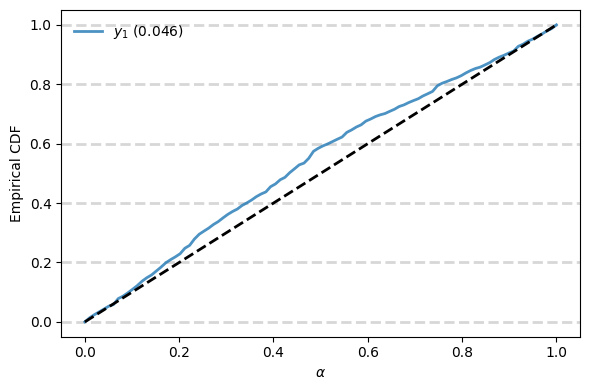

In [42]:
alphas = np.linspace(0, 1, 100)
sorted_indices = torch.argsort(pce_total, descending=True)  # or ascending=False

plt.figure(figsize=(6, 4))
for rank, d in enumerate(sorted_indices):
    d = d.item()
    cdf = cdfs_total[d].cpu().numpy()
    labelm = fr"$y_{d+1}$ ({pce_total[d]:.3f})"
    label = fr"$\rho_{{pca}}(y_1, y_2)$"
# ({pce_total[d]:.3f})
    plt.plot(alphas, cdf, color=colors[rank], 
             lw=2, alpha=0.8, label=labelm)

plt.plot(alphas, alphas, linestyle='--', color='black', lw=2)

plt.xlabel(r'$\alpha$')
plt.ylabel("Empirical CDF")
plt.grid(axis='y', linestyle='--', alpha=0.5, linewidth=2)
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()

filename = f"figures/combined/{data_name}/rel_plot_{prerank}_trained_on_{prerank}.png"
plt.savefig(filename, bbox_inches = 'tight', dpi=300)
plt.show()

#### Making figures for the paper

AssertionError: No checkpoint found in /mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/prerank2/camehl/households/model=mixture,seed=4,lambda=10.0,prerank=marginal/0/checkpoints

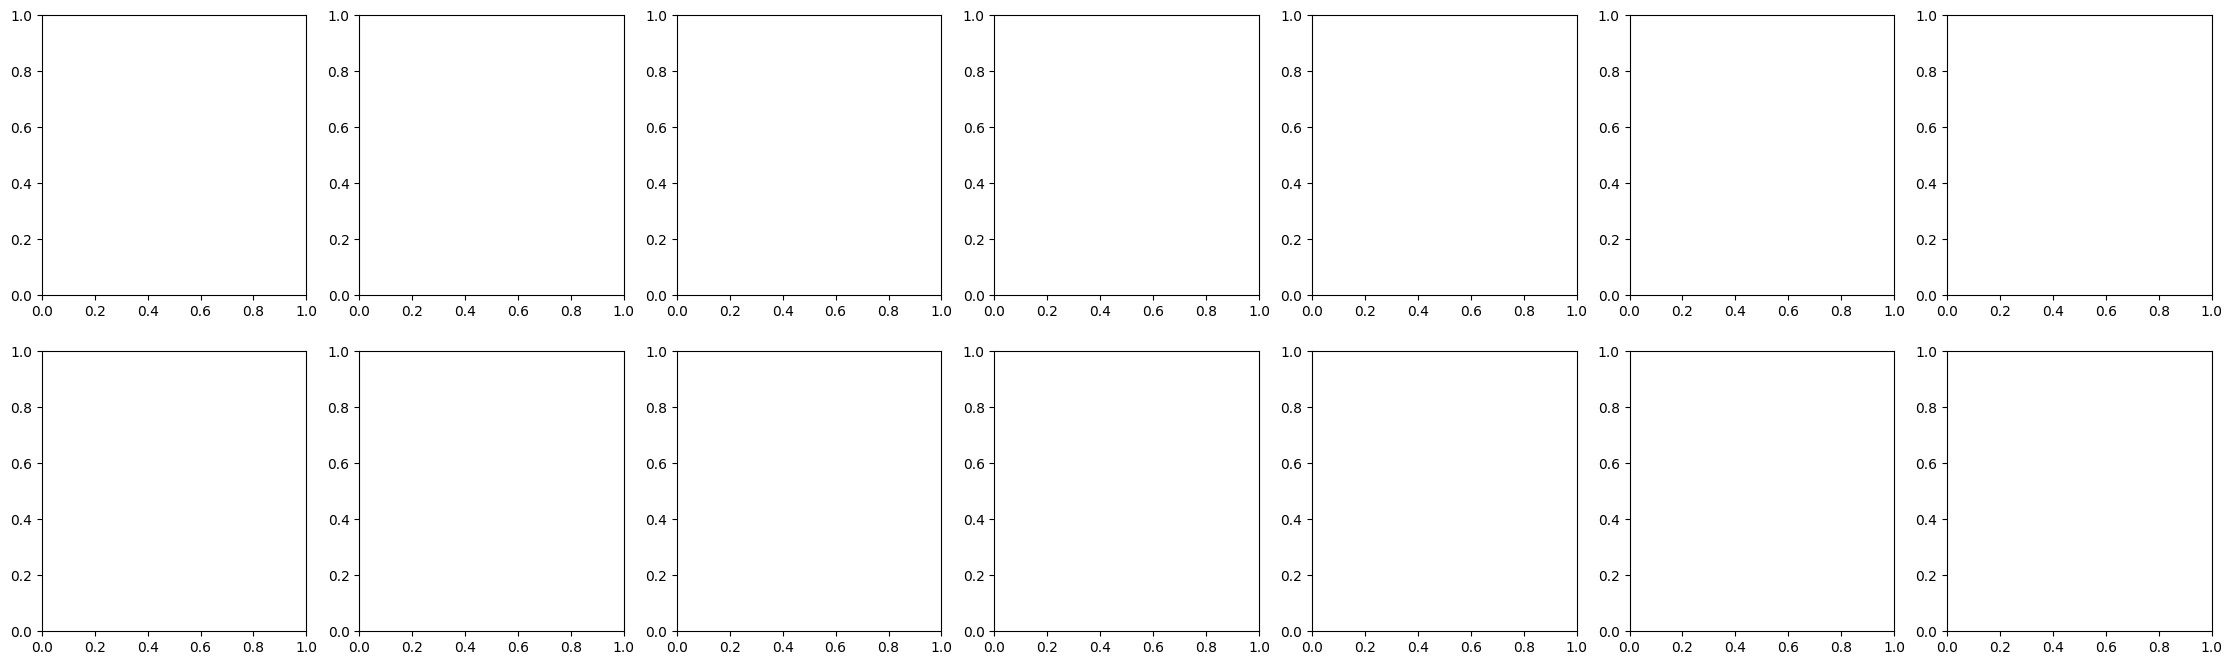

In [6]:
custom_title = {
    "marginal": "Marg.",
    "mean": "Loc.",
    "variance": "Scale",
    "dependency": "Dep.",
    "pca": "PCA",
    "density": "HDR",
    "cdf": "Copula"
}

preranks = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]
best_lambdas = [10.0, 10.0, 5.0, 10.0, 5.0, 1.0, 10.0]
seed = 4
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2",
    "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
    "#c5b0d5", "#c49c94"
]
alphas = np.linspace(0, 1, 100)

fig, axes = plt.subplots(2, 7, figsize=(28, 8))

for col, (train_prerank, l) in enumerate(zip(preranks, best_lambdas)):
    base_path = f"/mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/prerank2/{data_group}/{data_name}/model=mixture,seed={seed},lambda={l},prerank={train_prerank}/0/checkpoints"
    ckpt_files = glob.glob(os.path.join(base_path, "*.ckpt"))
    assert ckpt_files, f"No checkpoint found in {base_path}"
    ckpt_path = ckpt_files[0]

    model = MixtureLightningModule.load_from_checkpoint(ckpt_path)
    model.eval().to(config.device)

    test_loader = datamodule.test_dataloader()

    for i, eval_prerank in enumerate([train_prerank, "marginal"]):
        pces, cdfs = [], []
        for x, y, idx in test_loader:
            x = x.to(config.device)
            y = y.to(config.device)
            dist = model.predict(x)
            pce_val, _ = pce(dist, y, n_samples=model.hparams.es_num_samples, prerank=eval_prerank)
            #pce_val is of hsape 3 and cdfs are of shape 3, 100
            pces.append(pce_val)
            cdfs.append(_)
        pce_total = torch.stack(pces).mean(dim=0)
        cdfs_total = torch.stack(cdfs).mean(dim=0)

        ax = axes[i][col]

        vdots_shown = False
        D = cdfs_total.shape[0]
        for d in range(D):
            if i == 0:
                if q > 4:
                    y_vars = r"y_1, \dots, y_{" + str(q) + r"}"
                else:
                    y_vars = ", ".join([fr"y_{{{j+1}}}" for j in range(q)])
                label = fr"$\rho_{{{custom_title[train_prerank]}}}({y_vars})$" if d == 0 else None
            else:
                if q > 4:
                    if d == 0:
                        label = fr"$y_1$"
                    elif d == q - 1:
                        label = fr"$y_{{{q}}}$"
                    elif not vdots_shown:
                        label = fr"$\vdots$"
                        vdots_shown = True
                    else:
                        label = None
                else:
                    label = fr"$y_{{{d+1}}}$"
            ax.plot(alphas, cdfs_total[d].cpu().numpy(), color=colors[d], lw = 3.5, alpha=0.8, label=label)

        ax.plot(alphas, alphas, linestyle='--', color='black', lw = 3)

        ax.legend(loc='upper left', frameon=False)

        if i == 1:
            ax.set_xlabel(r'$\alpha$')
            ax.set_title("Evaluating on Marg.")
        if col == 0:
            ax.set_ylabel("Empirical CDF")
        ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth = 2)
        if i == 0:
            ax.set_title(f"Evaluating on {custom_title[train_prerank]}")

plt.tight_layout()
plt.savefig(f"figures/paper/rel_grid_prerank_{data_name}.png", bbox_inches='tight', dpi=400)
plt.show()
# plt.close()

#### Making box plots for PCE, NLL, Energy Score, MSE before and after reg (with prerank only for now)

In [ ]:
df = pd.read_csv('metrics-after-reg.csv')
df.head()

,data_name,seed,prerank,pce,nll,energy,mse
0,households,0,marginal,0.028741,3.295859,0.951055,0.663382
1,households,42,marginal,0.031749,3.270183,0.882693,0.554523
2,households,866,marginal,0.029671,3.396923,0.965792,0.652964
3,households,12,marginal,0.029982,3.423873,0.960883,0.667672
4,households,4,marginal,0.027437,3.255520,0.935410,0.623558


In [ ]:
avg_df = df.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df = avg_df[~avg_df['data_name'].isin(['rf1', 'rf2', 'sf2'])]
avg_df.shape

(126, 6)

In [ ]:
# df_before = pd.read_csv('metrics-before-reg.csv')
# df_before = df_before[~df_before['data_name'].isin(['rf1', 'rf2', 'sf2'])]
df_hdr = pd.read_csv('metrics-hdr.csv')
df_hdr = df_hdr[~df_hdr['data_name'].isin(['rf1', 'rf2', 'sf2'])]

In [ ]:
# avg_df_before = df_before.groupby(['data_name', 'prerank'], sort = False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
# avg_df_before = avg_df_before.groupby('data_name', sort=False)[['nll', 'energy', 'mse']].mean().reset_index()
# avg_df_before.shape
df_hdr.shape

(126, 4)

In [ ]:
df_hdr.head()

,data_name,prerank,pce,energy
0,households,marginal,0.028337,0.952953
1,households,mean,0.027010,0.947334
2,households,variance,0.026152,0.952341
3,households,dependency,0.022940,0.949789
4,households,pca,0.022417,0.953044


In [ ]:
avg_df.head(7)

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.029516,3.328471,0.939167,0.632420
1,households,mean,0.023898,3.395145,0.944452,0.628032
2,households,variance,0.021100,3.335899,0.936779,0.634394
3,households,dependency,0.020640,3.228757,0.921436,0.619659
4,households,pca,0.025954,3.330700,0.937192,0.621929
5,households,density,0.038680,3.292781,0.932650,0.628786
6,households,cdf,0.030640,3.354427,0.952433,0.658789


In [ ]:
datasets = df_hdr['data_name'].unique()
avg_df_filtered = avg_df[avg_df['data_name'].isin(datasets)]

# 3. keep only relevant columns
df_ours = avg_df_filtered[['data_name', 'prerank', 'pce', 'energy']]

In [ ]:
avg_scores_per_data = avg_df_before.groupby('data_name', sort=False)[['nll', 'energy', 'mse']].mean().reset_index()
avg_scores_per_data['prerank'] = 'none'
avg_scores_per_data['pce'] = 0
avg_scores_per_data.head()

,data_name,nll,energy,mse,prerank,pce
0,households,3.187087,0.918165,0.614488,none,0
1,air,5.650568,1.397655,0.937892,none,0
2,births1,1.181293,0.682644,0.759425,none,0
3,births2,-4.447253,0.922516,1.067480,none,0
4,wage,0.511141,0.711580,0.727497,none,0


In [ ]:
# Define custom order: "none" first, then the rest (sorted or explicitly ordered)
prerank_order = ['none', 'marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']

# Concat the two DataFrames
combined = pd.concat([avg_df, avg_scores_per_data], ignore_index=True)

# Convert 'prerank' column to categorical with desired order
combined['prerank'] = pd.Categorical(combined['prerank'], categories=prerank_order, ordered=True)

# Sort by dataset and then prerank
combined = combined.sort_values(['data_name', 'prerank']).reset_index(drop=True)
combined.head(8)

,data_name,prerank,pce,nll,energy,mse
0,air,none,0.000000,5.650568,1.397655,0.937892
1,air,marginal,0.039892,5.798495,1.421109,0.950752
2,air,mean,0.026328,5.812055,1.427127,0.949652
3,air,variance,0.026756,5.750404,1.417962,0.956134
4,air,dependency,0.026949,5.712583,1.405788,0.948559
5,air,pca,0.039238,5.787327,1.416858,0.944779
6,air,density,0.044818,5.666744,1.405010,0.942634
7,air,cdf,0.029004,5.798847,1.435200,0.993631


In [ ]:
plt.rcParams.update({'font.size': 10})
import matplotlib.patches as mpatches

In [ ]:
# Step 1: get only 'density' rows
density_df = df_ours[df_ours['prerank'] == 'density']

# Step 2: find top 4 datasets with highest PCE
top4 = density_df.nlargest(4, 'pce')['data_name']

# Step 3: remove those datasets entirely (all their preranks)
filtered_df_ours = df_ours[~df_ours['data_name'].isin(top4)]


In [ ]:
df = pd.read_csv('sensitivity_plot_s.csv')
# find top-4 datasets with highest PCE for density prerank
bad_datasets = (
    df[df["prerank"] == "density"]
    .groupby("data_name")["pce"]
    .mean()
    .nlargest(4)
    .index
)

# drop them
df_filtered = df[~df["data_name"].isin(bad_datasets)]

# now split
df_100 = df_filtered[df_filtered["s"] == 100].reset_index(drop=True)
df_1000 = df_filtered[df_filtered["s"] == 1000].reset_index(drop=True)

In [ ]:
# merge on dataset + prerank
merged = df_100.merge(df_1000, on=["data_name", "prerank"], suffixes=("_100", "_1000"))

# compute training time difference
merged["train_time_diff"] = merged["total_train_time_1000"] - merged["total_train_time_100"]

# average per prerank
summary = merged.groupby("prerank")["train_time_diff"].mean().reset_index()

# global average
global_avg = merged["train_time_diff"].mean()

print(summary)
print("Global average training time difference:", global_avg)

      prerank  train_time_diff
0         cdf        55.749517
1     density        85.584579
2  dependency         1.140590
3    marginal         0.606832
4        mean         0.319647
5         pca         0.710011
6    variance        -1.127095
Global average training time difference: 19.91436674479521


In [ ]:
# pivot so each row = dataset + prerank, columns = s values
pivot = df_filtered.pivot_table(
    index=["data_name", "prerank"],
    columns="s",
    values="pce"
).reset_index()

# rename for clarity
pivot = pivot.rename(columns={100: "pce_100", 1000: "pce_1000"})

# relative change: negative = improvement, positive = worse
pivot["pce_rel_change_%"] = (pivot["pce_100"] - pivot["pce_1000"]) / pivot["pce_1000"] * 100

# compute summary per prerank
summary = pivot.groupby("prerank")["pce_rel_change_%"].agg(
    median="median",
    mean="mean",
    improved=lambda x: (x > 0).sum(),
    worsened=lambda x: (x < 0).sum()
).reset_index()

print(summary)

      prerank    median      mean  improved  worsened
0         cdf  1.311419  0.480343         5         4
1     density  0.679000 -2.486157         6         4
2  dependency  1.274059  2.126243         7         3
3    marginal  0.218828 -0.058284         5         5
4        mean  0.889820 -1.618934         5         5
5         pca -2.163661  2.048035         4         6
6    variance -5.397414 -4.135218         3         7


In [ ]:
pivot.head(7)

s,data_name,prerank,pce_100,pce_1000,pce_rel_change_%
0,air,cdf,0.029199,0.030797,-5.187565
1,air,density,0.030475,0.031136,-2.122961
2,air,dependency,0.026837,0.027617,-2.827093
3,air,marginal,0.038037,0.039659,-4.089258
4,air,mean,0.029431,0.027317,7.739357
5,air,pca,0.034833,0.038817,-10.264448
6,air,variance,0.023774,0.024122,-1.440139


In [ ]:
len(df_100.data_name.unique())

10

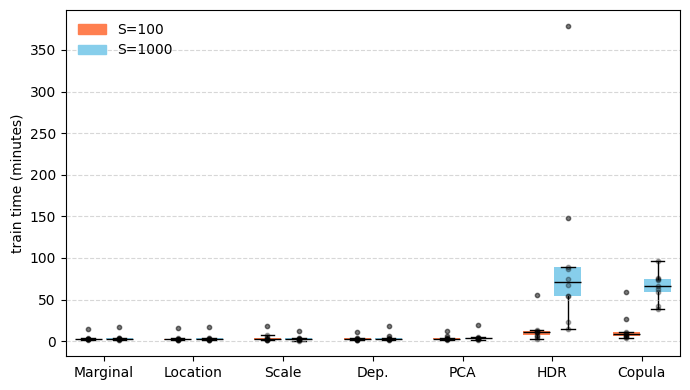

In [ ]:
preranks = df_filtered['prerank'].unique()
labels = ["Marginal", "Location", "Scale", "Dep.", "PCA", "HDR", "Copula"]

gap = 2.0      # space between prerank groups
delta = 0.7    # spacing between before and after in same group

data = []
xticks = []
positions = []

for i, p in enumerate(preranks):
    base = i * gap
    positions.extend([base, base + delta])  # before, after
    xticks.append(base + delta / 2)
    pce_100 = df_100[df_100['prerank'] == p]['total_train_time'].values
    pce_1000 = df_1000[df_1000['prerank'] == p]['total_train_time'].values
    # diff = np.abs(pce_before - pce_after)
    # data.append(diff)
    data.append(pce_100)
    data.append(pce_1000)

plt.figure(figsize=(7, 4))

box = plt.boxplot(data, positions=positions, widths=0.6, patch_artist=True, zorder=2,
                  flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=3, linestyle='none', alpha=0.3),
                  meanline=True, boxprops=dict(color='none'))


for i, patch in enumerate(box['boxes']):
    if i % 2 == 0:
        patch.set_facecolor("coral")  # before: orange opaque
    else:
        patch.set_facecolor("skyblue")  # after: blue opaque

for median in box['medians']:
    median.set_linewidth(1)
    median.set_color("black")  

# scatter the points
for i, d in enumerate(data):
    x = [positions[i]] * len(d)
    plt.scatter(x, d, color='black', s=10, zorder=3, alpha=0.3)

orange_patch = mpatches.Patch(color="coral", label='S=100')
blue_patch = mpatches.Patch(color="skyblue", label='S=1000')

plt.xticks(xticks, labels)
plt.ylabel("train time (minutes)")
plt.legend(handles=[orange_patch, blue_patch], loc='upper left', frameon=False)
plt.gca().set_axisbelow(False)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=4)
plt.tight_layout()
plt.savefig(f"figures/box_plot_s=100_s=1000_train_time.png", bbox_inches='tight', dpi=500)
plt.show()

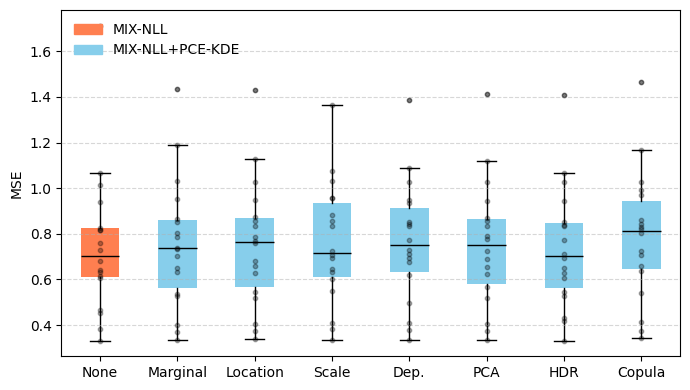

In [ ]:
preranks = combined['prerank'].unique()

data = [combined[combined['prerank'] == p]['mse'].values 
        for p in preranks]

plt.figure(figsize=(7, 4))

labels = ["None", "Marginal", "Location", "Scale", "Dep.", "PCA", "HDR", "Copula"]

flierprops = dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=3, linestyle='none', alpha=0.3) #outliers

box = plt.boxplot(data, tick_labels=labels, patch_artist=True, zorder = 2, 
                  flierprops=flierprops, meanline = True, boxprops=dict(color='none'))

for i, patch in enumerate(box['boxes']):
    if i==0:
        patch.set_facecolor("coral")
    else:
        patch.set_facecolor("skyblue") 
    # patch.set_edgecolor("#9673A6")
#color for NLL (opaque red) --> (227/255, 119/255, 119/255, 0.3)
#colors for Energy (opaque green) --> (44/255, 160/255, 44/255, 0.3)
#colors for PCE (opaque blue) --> (31/255, 119/255, 180/255, 0.7)
# for whisker in box['whiskers']:
#     whisker.set_color('#9673A6')  
#     whisker.set_linewidth(1.5)   

# for cap in box['caps']:
#     cap.set_color('#9673A6')
#     cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_linewidth(1)
    median.set_color("black")
# box['medians'][-1].set_color("#1a9012")
for i, p in enumerate(data):
    x = [i + 1] * len(p)
    plt.scatter(x, p, color='black', s=10, zorder=3, alpha = 0.3)

orange_patch = mpatches.Patch(color="coral", label='MIX-NLL')
green_patch = mpatches.Patch(color="skyblue", label='MIX-NLL+PCE-KDE')

plt.ylabel("MSE")
plt.tight_layout()
plt.legend(handles=[orange_patch, green_patch], loc='upper left', frameon=False)
plt.gca().set_axisbelow(False)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=4)
plt.savefig(f"figures/paper/box_plot_before_after_mse.png", bbox_inches='tight', dpi=500)
plt.show()

In [ ]:
avg_df_before = df_before.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df_before.head(10)

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.094671,3.187087,0.917795,0.614488
1,households,mean,0.091937,3.187087,0.917843,0.614488
2,households,variance,0.125329,3.187087,0.919684,0.614488
3,households,dependency,0.021782,3.187087,0.919045,0.614488
4,households,pca,0.066102,3.187087,0.918087,0.614488
5,households,density,0.097097,3.187087,0.917767,0.614488
6,households,cdf,0.149487,3.187087,0.916933,0.614488
7,air,marginal,0.099014,5.650568,1.397020,0.937892
8,air,mean,0.092714,5.650568,1.396897,0.937892
9,air,variance,0.198090,5.650568,1.400152,0.937892


In [ ]:
grouped = avg_df_before.groupby("data_name")[["nll", "energy", "mse"]].mean().reset_index()
grouped = grouped[~grouped['data_name'].isin(['rf1', 'rf2', 'sf2'])]

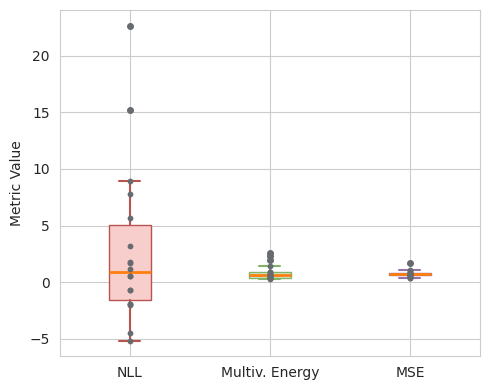

In [ ]:
plt.figure(figsize=(5, 4))

flierprops = dict(marker='o', markerfacecolor='#6C8EBF', markeredgecolor='#676B70', markersize=4, linestyle='none') #outliers
box = plt.boxplot([grouped[col].values for col in ["nll", "energy", "mse"]],
                  patch_artist=True, tick_labels=["NLL", "Multiv. Energy", "MSE"], flierprops=flierprops)

for patch in box['boxes']:
    patch.set_facecolor("#DAE8FC")
    patch.set_edgecolor("#6C8EBF")

colors = ['#F8CECC', '#D5E8D4', '#E1D5E7']  # one color per box
edge_colors = ['#B85450', "#82B366", "#9673A6"]
for patch, color, edge in zip(box['boxes'], colors, edge_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(edge)  # optional

for median in box['medians']:
    median.set_linewidth(2)

for i, edge in enumerate(edge_colors):
    box['caps'][2*i].set_color(edge)     # bottom cap
    box['caps'][2*i + 1].set_color(edge) # top cap
    box['caps'][2*i].set_linewidth(1.5)
    box['caps'][2*i+1].set_linewidth(1.5)

for i, edge in enumerate(edge_colors):
    box['whiskers'][2*i].set_color(edge)     
    box['whiskers'][2*i + 1].set_color(edge) 
    box['whiskers'][2*i].set_linewidth(1.5)
    box['whiskers'][2*i+1].set_linewidth(1.5)


for i, col in enumerate(["nll", "energy", "mse"]):
    plt.scatter([i + 1] * len(grouped), grouped[col].values, color='#676B70', s=10, zorder=3)

plt.ylabel("Metric Value")
plt.tight_layout()
plt.savefig(f"figures/paper/box_plot_before_scores.png", bbox_inches='tight', dpi=500)
plt.show()